# Determine sample properties needed to measure abundance gradients

In [1]:
import numpy as np

from astropy import units, coordinates
from tqdm import tqdm
import os
import pandas as pd
from scipy.stats import binned_statistic_2d, binned_statistic_dd
from astropy.table import Table

import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use('figure_style.mplstyle')

from my_utils import generate_random_sample, run_gradient_sim, plot_sun_and_gc, generate_distributed_sample

/uufs/astro.utah.edu/common/home/u1371365/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Read in synthetic populations

In [2]:
# Load in the data
all_csv_files = [
    f.name
    for f in os.scandir("../hge_gums_marshall")
    if f.name.endswith(".csv") and f.name.startswith("hge_gums_marshall_")
]

# Concatenate all files
all_stars = [pd.read_csv(f"../hge_gums_marshall/{f}") for f in all_csv_files]
all_stars = pd.concat(all_stars)
print(len(all_stars['l']))
print(all_stars.columns)

# Convert (l,b,dist) to Galactic (R,Z,phi)
all_coords = coordinates.SkyCoord(
    frame="galactic",
    l=all_stars["l"],
    b=all_stars["b"],
    distance=all_stars["Dist"],
    unit=(units.deg, units.deg, units.kpc),
)

all_coords = all_coords.transform_to(coordinates.Galactocentric)
gal_x = all_coords.x / units.kpc
gal_y = all_coords.y / units.kpc
gal_z = all_coords.z / units.kpc
gal_r = np.sqrt(((all_coords.x) ** 2.0) + ((all_coords.y) ** 2.0)) / units.kpc


5612873
Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist',
       'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR',
       'A_Ks', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius',
       'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3', '2MASS_J',
       '2MASS_H', '2MASS_Ks', 'IRAC_3.6', 'IRAC_4.5'],
      dtype='object')


In [3]:
#Define some useful cuts
distance_cut = (all_stars['Dist'] > 6.) #assume we can remove stars within 6 kpc of the sun
hmag_cut = (all_stars['2MASS_H'] < 16) #limit to things visible to use
midplane = (abs(gal_z) < 0.5) #within 0.5 kpc of the midplane

## View the data

/tmp/ipykernel_708462/2641776493.py:22: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(im_xy.T), aspect='auto', origin='lower',
/uufs/astro.utah.edu/common/home/u1371365/post-main-sequence/gail_hge_targeting/my_utils.py:267: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(
/tmp/ipykernel_708462/2641776493.py:32: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(im_rz.T), aspect='auto', origin='lower',


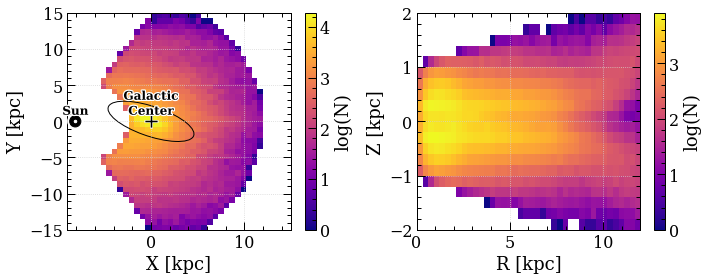

In [4]:
#Face-on, top-down, side-on

xr = [-9,15]
yr = [-15,15]
zr = [-2,2]
rr = [0,12]
n_xbins = 40
n_ybins = n_xbins
n_zbins = 20
n_rbins = n_xbins

show = np.logical_and.reduce([distance_cut, hmag_cut])

im_xy, xe, ye, bn = binned_statistic_2d(gal_x[show], gal_y[show], all_stars['l'][show], statistic='count',
                                        range=[xr,yr], bins=[n_xbins,n_ybins])
im_rz, xe, ye, bn = binned_statistic_2d(gal_r[show], gal_z[show], all_stars['l'][show], statistic='count',
                                        range=[rr,zr], bins=[n_rbins,n_zbins])

fig = plt.figure(figsize=(10,4))

ax = plt.subplot(121)
plt.imshow(np.log10(im_xy.T), aspect='auto', origin='lower',
           extent=[min(xr),max(xr),min(yr),max(yr)])
plt.colorbar(label='log(N)')
plt.xlim(xr)
plt.ylim(yr)
plt.xlabel('X [kpc]')
plt.ylabel('Y [kpc]')
plot_sun_and_gc(ax, size=0.5, add_bar=True)

ax = plt.subplot(122)
plt.imshow(np.log10(im_rz.T), aspect='auto', origin='lower',
           extent=[min(rr),max(rr),min(zr),max(zr)])
plt.colorbar(label='log(N)')
plt.xlim(rr)
plt.ylim(zr)
plt.xlabel('R [kpc]')
plt.ylabel('Z [kpc]')

fig.tight_layout()


## Generate 4D X/Y/Z/FeH distribution for upsampling later

Only include points brighter than H<16 and farther than d>6 kpc.

(42, 60, 16, 36)


/tmp/ipykernel_708462/2854576233.py:18: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(xyzm_dist[:,:,round(n_gal_z_bins/2),30]).T, origin='lower')


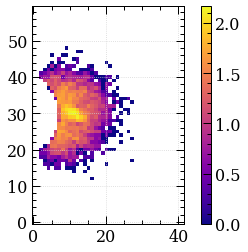

In [5]:
use = np.logical_and.reduce([distance_cut, hmag_cut])
gal_x_rng = [-6,15]
gal_y_rng = [-15,15]
gal_z_rng = [-2,2]
feh_rng = [-1.2,0.6]
n_gal_x_bins = round((gal_x_rng[1]-gal_x_rng[0])/0.5)
n_gal_y_bins = round((gal_y_rng[1]-gal_y_rng[0])/0.5)
n_gal_z_bins = round((gal_z_rng[1]-gal_z_rng[0])/0.25)
n_feh_bins = round((feh_rng[1]-feh_rng[0])/0.05)
data = np.column_stack((gal_x[use], gal_y[use], gal_z[use], all_stars['Fe/H_evolved'][use]))
xyzm_dist, be, bn = binned_statistic_dd(data, gal_x[use], statistic='count', 
                                        bins=(n_gal_x_bins,n_gal_y_bins,n_gal_z_bins,n_feh_bins),
                                        range=[gal_x_rng,gal_y_rng,gal_z_rng,feh_rng])
print(xyzm_dist.shape)
#print(max(xyzm_dist.flatten()))
#_=plt.hist(np.log10(xyzm_dist.flatten()), range=[0,2], bins=40)
#_=plt.hist(all_stars['Fe/H_evolved'][use], bins=40)
plt.imshow(np.log10(xyzm_dist[:,:,round(n_gal_z_bins/2),30]).T, origin='lower')
plt.colorbar()

## Characterize "true" gradient

In [6]:
#Fit all noiseless data with different |Z|, with and without excluding R<3kpc
z_max_array = [1.0] #, 0.25, 0.5, 0.75, 1.0, 2.0]
r_min_array = [0, 3.5]

for i_z_max, this_z_max in enumerate(z_max_array):
    for i_r_min, this_r_min in enumerate(r_min_array):
        gd = np.logical_and.reduce([distance_cut, hmag_cut, 
                                    abs(gal_z.value) < this_z_max,
                                    gal_r.value > this_r_min])
        n_gd = np.nansum(gd)
        slope, slope_err, median_slopes, median_errs = run_gradient_sim(all_stars[gd], n_gd, dist_uncertainty=0.0, feh_uncertainty=0.0)
        print('|Z_max|={:.2f} kpc, R_min={:.1f} kpc: {:.3f} dex=kpc'.format(this_z_max, this_r_min, median_slopes[0]))


|Z_max|=1.00 kpc, R_min=0.0 kpc: -0.055 dex=kpc
|Z_max|=1.00 kpc, R_min=3.5 kpc: -0.063 dex=kpc


/uufs/astro.utah.edu/common/home/u1371365/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/uufs/astro.utah.edu/common/home/u1371365/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


### Results

- There are enough stars in the midplane that including stars up to |Z|=2 kpc doesn't change the slope, as long as the midplane is well-sampled.
- If the bulge (with its flatter gradient) is included, the simulation returns a slope of -0.055 dex/kpc.
- If the bulge is excluded, by requiring $R_{\rm GC} > 3.5$ kpc, the simulation returns a slope of -0.063 dex/kpc.

In [7]:
true_gradient_all = -0.055
true_gradient_disk = -0.063

## Test effects of increasing abundance and distance uncertainties

In [8]:
#Do matrix of abundance uncertainty x distance uncertainty 

delta_abund_unc = 0.03
abund_uncertainty_array = np.arange(0.01,0.12,delta_abund_unc) #[0.01, 0.05, 0.1] #dex
delta_dist_unc = 0.1
dist_uncertainty_array = np.arange(0.01,0.4,delta_dist_unc) #[0.05, 0.15, 0.3] #fraction of d
slope_array_all = np.full((len(abund_uncertainty_array),len(dist_uncertainty_array)), fill_value=np.nan)
slope_err_array_all = np.full_like(slope_array_all, fill_value=np.nan)
slope_array_disk = np.full_like(slope_array_all, fill_value=np.nan)
slope_err_array_disk = np.full_like(slope_array_all, fill_value=np.nan)

for i_abund_uncertainty, this_abund_uncertainty in enumerate(abund_uncertainty_array):
    for i_dist_uncertainty, this_dist_uncertainty in enumerate(dist_uncertainty_array):
        #All stars
        gd = np.logical_and.reduce([distance_cut, hmag_cut, 
                                    abs(gal_z.value) < 1.0])
        n_gd = np.nansum(gd)
        slope, slope_err, median_slopes, median_errs = run_gradient_sim(all_stars[gd], n_gd, 
                                                                        dist_uncertainty=this_dist_uncertainty, 
                                                                        feh_uncertainty=this_abund_uncertainty,
                                                                        add_noise=True)
        slope_array_all[i_abund_uncertainty,i_dist_uncertainty] = median_slopes[0]
        slope_err_array_all[i_abund_uncertainty,i_dist_uncertainty] = slope_err[0]
        #Disk stars
        gd = np.logical_and.reduce([distance_cut, hmag_cut, 
                                    abs(gal_z.value) < 1.0,
                                    gal_r.value > 3.5])
        n_gd = np.nansum(gd)
        slope, slope_err, median_slopes, median_errs = run_gradient_sim(all_stars[gd], n_gd, 
                                                                        dist_uncertainty=this_dist_uncertainty, 
                                                                        feh_uncertainty=this_abund_uncertainty,
                                                                        add_noise=True)
        slope_array_disk[i_abund_uncertainty,i_dist_uncertainty] = median_slopes[0]
        slope_err_array_disk[i_abund_uncertainty,i_dist_uncertainty] = slope_err[0]
        #print('sig_abund={}, sig_d={}'.format())


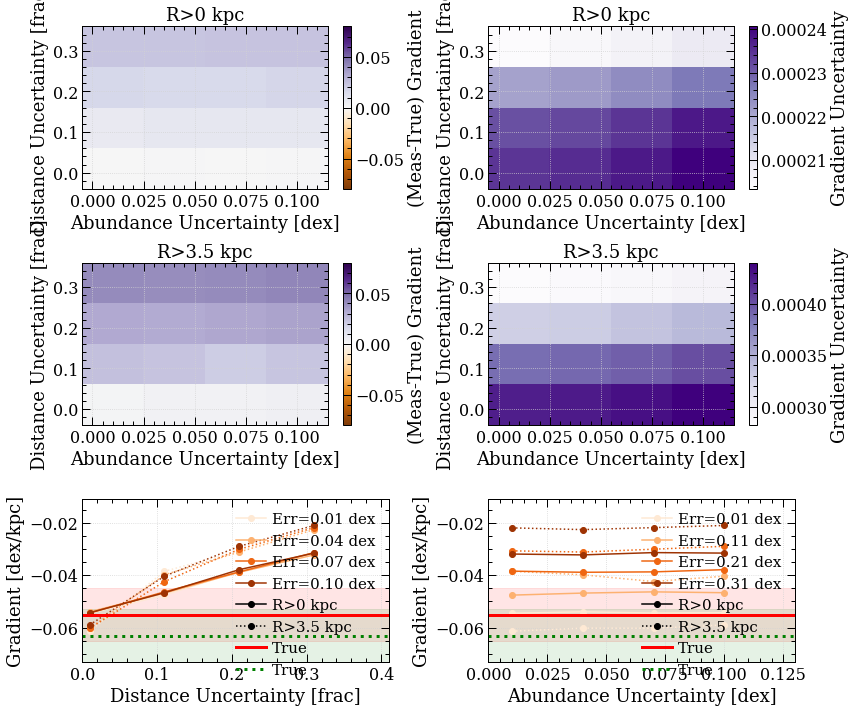

In [9]:
fig = plt.figure(figsize=(12,10))

ax = plt.subplot(321)
plt.imshow(slope_array_all.T-true_gradient_all, origin='lower', aspect='auto',
           extent=[min(abund_uncertainty_array)-delta_abund_unc/2.,max(abund_uncertainty_array)+delta_abund_unc/2.,
                   min(dist_uncertainty_array)-delta_dist_unc/2.,max(dist_uncertainty_array)+delta_dist_unc/2.],
           cmap='PuOr', vmin=-0.08, vmax=0.08)
plt.colorbar(label='(Meas-True) Gradient')
plt.xlabel('Abundance Uncertainty [dex]')
plt.ylabel('Distance Uncertainty [frac]')
plt.title('R>0 kpc')

ax = plt.subplot(322)
plt.imshow(slope_err_array_all.T, origin='lower', aspect='auto',
           extent=[min(abund_uncertainty_array)-delta_abund_unc/2.,max(abund_uncertainty_array)+delta_abund_unc/2.,
                   min(dist_uncertainty_array)-delta_dist_unc/2.,max(dist_uncertainty_array)+delta_dist_unc/2.],
           cmap='Purples')
plt.colorbar(label='Gradient Uncertainty')
plt.xlabel('Abundance Uncertainty [dex]')
plt.ylabel('Distance Uncertainty [frac]')
plt.title('R>0 kpc')

ax = plt.subplot(323)
plt.imshow(slope_array_disk.T-true_gradient_disk, origin='lower', aspect='auto',
           extent=[min(abund_uncertainty_array)-delta_abund_unc/2.,max(abund_uncertainty_array)+delta_abund_unc/2.,
                   min(dist_uncertainty_array)-delta_dist_unc/2.,max(dist_uncertainty_array)+delta_dist_unc/2.],
           cmap='PuOr', vmin=-0.08, vmax=0.08)
plt.colorbar(label='(Meas-True) Gradient')
plt.xlabel('Abundance Uncertainty [dex]')
plt.ylabel('Distance Uncertainty [frac]')
plt.title('R>3.5 kpc')

ax = plt.subplot(324)
plt.imshow(slope_err_array_disk.T, origin='lower', aspect='auto',
           extent=[min(abund_uncertainty_array)-delta_abund_unc/2.,max(abund_uncertainty_array)+delta_abund_unc/2.,
                   min(dist_uncertainty_array)-delta_dist_unc/2.,max(dist_uncertainty_array)+delta_dist_unc/2.],
           cmap='Purples')
plt.colorbar(label='Gradient Uncertainty')
plt.xlabel('Abundance Uncertainty [dex]')
plt.ylabel('Distance Uncertainty [frac]')
plt.title('R>3.5 kpc')

#Direct dependence
abund_unc_colors = mpl.colormaps['Oranges'](np.linspace(0.1, 0.9, len(abund_uncertainty_array)))
dist_unc_colors = mpl.colormaps['Oranges'](np.linspace(0.1, 0.9, len(dist_uncertainty_array)))
gradient_rng = [min([min(slope_array_all.flatten()),min(slope_array_disk.flatten()),true_gradient_all,true_gradient_disk])-0.01,
                max([max(slope_array_all.flatten()),max(slope_array_disk.flatten()),true_gradient_all,true_gradient_disk])+0.01]

ax = plt.subplot(325)
for i_abund_uncertainty, this_abund_uncertainty in enumerate(abund_uncertainty_array):
    plt.plot(dist_uncertainty_array, slope_array_all[i_abund_uncertainty,:], '-o',
             color=abund_unc_colors[i_abund_uncertainty],
             label='Err={:.2f} dex'.format(this_abund_uncertainty))
    plt.plot(dist_uncertainty_array, slope_array_disk[i_abund_uncertainty,:], ':o', 
             color=abund_unc_colors[i_abund_uncertainty])
plt.plot([-50,-50],[-100,-100],'o-', color='k', label='R>0 kpc')
plt.plot([-50,-50],[-100,-100],'o:', color='k', label='R>3.5 kpc')
plt.axhline(true_gradient_all, c="red", lw=3, label="True")
plt.axhspan(true_gradient_all - 0.01, true_gradient_all + 0.01, color="red", alpha=0.1)
plt.axhline(true_gradient_disk, c="green", lw=3, ls=':', label="True")
plt.axhspan(true_gradient_disk - 0.01, true_gradient_disk + 0.01, color="green", alpha=0.1)
plt.legend()
plt.xlim([0,max(dist_uncertainty_array+delta_dist_unc)])
plt.ylim(gradient_rng)
plt.xlabel('Distance Uncertainty [frac]')
plt.ylabel('Gradient [dex/kpc]')

ax = plt.subplot(326)
for i_dist_uncertainty, this_dist_uncertainty in enumerate(dist_uncertainty_array):
    plt.plot(abund_uncertainty_array, slope_array_all[:,i_dist_uncertainty], '-o', 
             color=dist_unc_colors[i_dist_uncertainty],
             label='Err={:.2f} dex'.format(this_dist_uncertainty))
    plt.plot(abund_uncertainty_array, slope_array_disk[:,i_dist_uncertainty], ':o', 
             color=dist_unc_colors[i_dist_uncertainty])
plt.plot([-50,-50],[-100,-100],'o-', color='k', label='R>0 kpc')
plt.plot([-50,-50],[-100,-100],'o:', color='k', label='R>3.5 kpc')
plt.axhline(true_gradient_all, c="red", lw=3, label="True")
plt.axhspan(true_gradient_all - 0.01, true_gradient_all + 0.01, color="red", alpha=0.1)
plt.axhline(true_gradient_disk, c="green", lw=3, ls=':', label="True")
plt.axhspan(true_gradient_disk - 0.01, true_gradient_disk + 0.01, color="green", alpha=0.1)
plt.legend()
plt.xlim([0,max(abund_uncertainty_array+delta_abund_unc)])
plt.ylim(gradient_rng)
plt.xlabel('Abundance Uncertainty [dex]')
plt.ylabel('Gradient [dex/kpc]')

fig.tight_layout()

### Results

- Note that since the gradients are <i>negative</i>, a positive number on the left-hand colorbars above (Meas-True Gradient) mean a <i>flatter</i> slope was measured than reality.
- Abundance uncertainties have little effect in this limited test. (This assumes symmetric, gaussian scatter!)
- Distance uncertainties matter a lot more than abundance uncertainties. There is always a systematic bias towards flatter slopes, because there are more metal-rich bulge stars to scatter outwards than metal-poorer disk stars to scatter inwards.
- Keeping distance uncertainties within 10% (everything else held ideal) is needed to keep the shifts within 0.01 dex/kpc.


## Test effects of sample size and distribution

In [10]:
#For 1 (or more?) uncertainty scenarios, test a range of N_stars and distributions

dist_unc0 = 0.15
abund_unc0 = 0.05

n_stars_array = np.logspace(2,5.7,50)
outer_rad_array = [4.0, 8.0, 15.0]
rad_distrib_array = np.array([[90.,10.,0.], #Fraction of stars in R=[0-5/5-8/8+] kpc
                              [75.,25.,0.],
                              [50.,49.,1.],
                              [80.,15.,5.],
                              [20.,70.,10.],
                              [50.,25.,25.]])
rad_distrib_array_actual = np.full_like(rad_distrib_array, fill_value=0.0)
n_rad_distrib = rad_distrib_array.shape[0]
n_radii = rad_distrib_array.shape[1]
slope_array = np.full((len(n_stars_array),n_rad_distrib), fill_value=np.nan)
med_slope_array = np.full_like(slope_array, fill_value=np.nan)
slope_err_array = np.full_like(slope_array, fill_value=np.nan)
n_stars_array_actual = np.full_like(slope_array, fill_value=0.0)

#Downselect all_stars to what we might actually consider targeting, plus other effects
gd = np.logical_and.reduce([distance_cut, 
                            #all_stars['Fe/H_evolved'] > -0.25, #bias against MPer stars
                            #abs(gal_z.value)>0.25, #Uh oh no midplane
                            #np.logical_or.reduce([abs(all_stars['b']) > 2, 
                            #                      np.logical_and.reduce([all_stars['l'] > 10.,
                            #                                             all_stars['l'] < 350.])]), #Uh oh no midplane
                            #np.logical_or.reduce([all_stars['l'] < 10., all_stars['l'] > 180.]), #Uh oh no APO
                            hmag_cut])
n_gd = np.nansum(gd)

#Perturb distances and abundances by their uncertainties
uncertain_dists = [abs(np.random.normal(d, d * dist_unc0)) for d in all_stars["Dist"]]
uncertain_abunds = [np.random.normal(f, abund_unc0) for f in all_stars["Fe/H_evolved"]]

dat = Table()
dat['l'] = all_stars['l']
dat['b'] = all_stars['b']
dat['Dist'] = uncertain_dists
dat['Fe/H_evolved'] = uncertain_abunds

for i_n_stars, this_n_stars in enumerate(n_stars_array):
    for i_rad_distrib in range(n_rad_distrib):
        percents = np.array(rad_distrib_array[i_rad_distrib,:]/100.)
        distributed_stars = generate_distributed_sample(dat[gd], this_n_stars, 
                                                        outer_radii=outer_rad_array, percents=percents, verbose=True)
        n_distributed_stars = len(distributed_stars['l'])
        if n_distributed_stars < this_n_stars:
            n_stars_array_actual[i_n_stars,i_rad_distrib] = n_distributed_stars
        else:
            n_stars_array_actual[i_n_stars,i_rad_distrib] = this_n_stars

        if abs(np.log10(this_n_stars)-4.0) < 0.05:
            for i_radius, this_radius in enumerate(outer_rad_array):
                if i_radius==0:
                    inner_radius = 0.0
                else:
                    inner_radius = outer_rad_array[i_radius-1]
                stars_in_here = np.nansum(np.logical_and.reduce([distributed_stars['gal_r'] > inner_radius,
                                                                 distributed_stars['gal_r'] < this_radius]))
                rad_distrib_array_actual[i_rad_distrib,i_radius] = float(stars_in_here)/float(n_distributed_stars)
            print(n_distributed_stars, percents, rad_distrib_array_actual[i_rad_distrib,:])

        slope, slope_err, median_slopes, median_errs = run_gradient_sim(distributed_stars, this_n_stars, 
                                                                        dist_uncertainty=dist_unc0, feh_uncertainty=abund_unc0, 
                                                                        add_noise=False)
        slope_array[i_n_stars,i_rad_distrib] = slope[0]
        med_slope_array[i_n_stars,i_rad_distrib] = median_slopes[0]
        slope_err_array[i_n_stars,i_rad_distrib] = slope_err[0]
        

Bin 1: 399839 avail, 90 needed
Bin 2: 164443 avail, 10 needed
Bin 3: 36859 avail, 0 needed
Bin 1: 399839 avail, 75 needed


/uufs/astro.utah.edu/common/home/u1371365/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/uufs/astro.utah.edu/common/home/u1371365/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Bin 2: 164443 avail, 25 needed
Bin 3: 36859 avail, 0 needed
Bin 1: 399839 avail, 50 needed
Bin 2: 164443 avail, 49 needed
Bin 3: 36859 avail, 1 needed
Bin 1: 399839 avail, 80 needed
Bin 2: 164443 avail, 15 needed
Bin 3: 36859 avail, 5 needed
Bin 1: 399839 avail, 20 needed
Bin 2: 164443 avail, 70 needed
Bin 3: 36859 avail, 10 needed
Bin 1: 399839 avail, 50 needed
Bin 2: 164443 avail, 25 needed
Bin 3: 36859 avail, 25 needed
Bin 1: 399839 avail, 107 needed
Bin 2: 164443 avail, 11 needed
Bin 3: 36859 avail, 0 needed
Bin 1: 399839 avail, 89 needed
Bin 2: 164443 avail, 29 needed
Bin 3: 36859 avail, 0 needed
Bin 1: 399839 avail, 59 needed
Bin 2: 164443 avail, 58 needed
Bin 3: 36859 avail, 1 needed
Bin 1: 399839 avail, 95 needed
Bin 2: 164443 avail, 17 needed
Bin 3: 36859 avail, 5 needed
Bin 1: 399839 avail, 23 needed
Bin 2: 164443 avail, 83 needed
Bin 3: 36859 avail, 11 needed
Bin 1: 399839 avail, 59 needed
Bin 2: 164443 avail, 29 needed
Bin 3: 36859 avail, 29 needed
Bin 1: 399839 avail, 127 

In [1]:
from abundance_gradients_helper_functions import flatten_gradient, apply_lombscargle

Text(0.5, 1.0, '$\\sigma_d$/$d$=15.0%, $\\sigma_X$=0.05 dex')

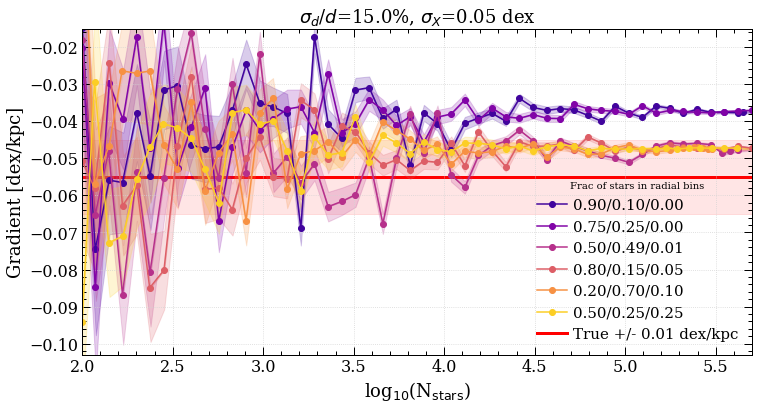

In [11]:
fig = plt.figure(figsize=(12,6))

gradient_rng = [min([true_gradient_all,true_gradient_disk])-0.04,
                max([true_gradient_all,true_gradient_disk])+0.04]
rad_distrib_colors = mpl.colormaps['plasma'](np.linspace(0.1, 0.9, n_rad_distrib))

ax = plt.subplot(111)
for i_rad_distrib in range(n_rad_distrib):
    p1,p2,p3 = np.array(rad_distrib_array_actual[i_rad_distrib,0:3])
    #plt.plot(np.log10(n_stars_array), slope_array[:,i_rad_distrib], 'o-', 
    plt.plot(np.log10(n_stars_array_actual[:,i_rad_distrib]), med_slope_array[:,i_rad_distrib], 'o-',
             color=rad_distrib_colors[i_rad_distrib], zorder=2, 
             label='{:.2f}/{:.2f}/{:.2f}'.format(p1,p2,p3))
    #plt.errorbar(np.log10(n_stars_array), slope_array[:,i_rad_distrib], marker='.', color='w',
    #             yerr=slope_err_array[:,3], ecolor='gray', capsize=0, ls='', zorder=1)
    plt.fill_between(np.log10(n_stars_array), med_slope_array[:,i_rad_distrib],
                     y2=med_slope_array[:,i_rad_distrib]+slope_err_array[:,3],
                     color=rad_distrib_colors[i_rad_distrib], alpha=0.2)
    plt.fill_between(np.log10(n_stars_array), med_slope_array[:,i_rad_distrib],
                     y2=med_slope_array[:,i_rad_distrib]-slope_err_array[:,3],
                     color=rad_distrib_colors[i_rad_distrib], alpha=0.2)

plt.axhline(true_gradient_all, c="red", lw=3, label="True +/- 0.01 dex/kpc", zorder=0)
plt.axhspan(true_gradient_all - 0.01, true_gradient_all + 0.01, color="red", alpha=0.1, zorder=0)
#plt.axhline(true_gradient_disk, c="green", lw=3, ls=':', label="True", zorder=0)
#plt.axhspan(true_gradient_disk - 0.01, true_gradient_disk + 0.01, color="green", alpha=0.1, zorder=0)
plt.legend(title='Frac of stars in radial bins')
plt.xlim([2,5.7])
plt.ylim(gradient_rng)
plt.xlabel(r'log$_{10}$(N$_{\rm stars}$)')
plt.ylabel('Gradient [dex/kpc]')
plt.title(r'$\sigma_d$/$d$={:.1f}%, $\sigma_X$={:.2f} dex'.format(dist_unc0*100, abund_unc0))


## Results
- Distance uncertainties always scatter things to flatter gradients. <b>HAVE TO GET GOOD DISTANCES.</b>
- The measured gradient doesn't change as the total number of stars increases past $\log{N} \sim 4.2$. The precision increases a bit past that, but the value itself stays flat.
- This is likely because these gradients are measured from binned medians, which alleviates the underlying density distribution. If we measure directly from the points (as a simple linear fit), everything is systematically shifted higher -- having the outer disk stars still helps, but not as much.
- We need stars beyond the solar circle to pin down the disk gradient, outside of the bulge. We don't need <i>many</i> of them, but we do <i>need</i> them.
- To the above, even 5% of the sample with R>8 kpc helps. 5% of 15,000 is 750 stars.
- TO DO: Update the fitting to include both distance and abundance uncertainties.


## Test effects of other choices

### What if we have a bias against metal-poor stars?

- Assessed by adding "all_stars['Fe/H_evolved'] > X" to the cell above.
- $\rm X=-1$ dex: no change
- $\rm X=-0.5$ dex: shifts gradients very slightly flatter at the level of 0.002 dex/kpc, does not change behavior due to the radial distribution of the sample
- $\rm X=-0.25$ dex: shifts all gradients to $\sim 0.015$ dex/kpc too high, likely because it's preferentially removing those valuable outer disk stars.

### What if we don't have APO?

- Assessed by adding "np.logical_or.reduce([all_stars['l'] < 10., all_stars['l'] > 180.])" to the cell above.
- No change, <i>given the same total sample size</i>
- Because LCO can see so much of the disk, for a single gradient measurement, APO is not essential.

### What if we can't reach the midplane at inner longitudes?

- Assessed by restricting to $|b| > 0.2^\circ$ inside $|l| = 10^\circ$: "np.logical_or.reduce([abs(all_stars['b']) > 0.2, np.logical_and.reduce([all_stars['l'] > 10., all_stars['l'] < 350.])])"
- Limiting to 0.2 deg doesn't change anything.
- If I go all the way up to $|b|>2^\circ$ for that inner region, things do get flatter, because the thick disk has an intrinsically flatter gradient. But the area outside of $|l| = 10^\circ$ is large enough to provide low $|Z|$ stars as long as we can observe lots of $b \sim 0^\circ$ there.

In [ ]:
# helper_fn(fe_h_min= Something, x,y,z, )